In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from src import utils

### data

In [2]:
def get_data_sample_weight(data_type):
    data_hits = []
    enrichment = []
    for rank in rank_list:
        df = pd.read_csv("/home/jg2447/slayman/motif_inference/result/UnifyParaSearch/%s/enrichment/%s_100.txt" % (data_type, rank), sep="\t", index_col=0)
        enrichment.append(df["250"].mean())

        data_hits.append(df["250"].values)
        if rank == "RankSPP":
            spp_hits = df["250"].values
        elif rank == "RankColdness":
            cold_hits = df["250"].values


    e_improve = (np.array(enrichment) - enrichment[0])/enrichment[0]
    e_improve_data = pd.DataFrame(e_improve).transpose()

    spp_p_list = []
    cold_p_list = []
    for i in range(len(data_hits)):
        spp_p_list.append(utils.stat_sig_test(data_hits[i], spp_hits))
        cold_p_list.append(utils.stat_sig_test(data_hits[i], cold_hits))

    data_p_list = []
    for i in range(len(spp_p_list)):
        if spp_p_list[i] < 0.05 and cold_p_list[i] < 0.05:
            data_p_list.append("*+")
        elif spp_p_list[i] < 0.05 and cold_p_list[i] >= 0.05:
            data_p_list.append("*")
        elif spp_p_list[i] >= 0.05 and cold_p_list[i] < 0.05:
            data_p_list.append("+")
        elif spp_p_list[i] >= 0.05 and cold_p_list[i] >= 0.05:
            data_p_list.append("")

    return((e_improve_data.values[0], np.array(data_p_list)))

In [3]:
def get_data_sample_length(data_type):
    enrichment = []
    nbp_list = [10, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200]
    
    for nn in nbp_list:
        df = pd.read_csv("/home/jg2447/slayman/motif_inference/result/UnifyParaSearch/%s/enrichment/RankSPP_%d.txt" % (data_type, nn), sep="\t", index_col=0)
        enrichment.append(df["250"].mean())
    e_len_improve = (np.array(enrichment) - enrichment[5])/enrichment[5]
    return(pd.DataFrame(e_len_improve))

In [4]:
alpha_list_para = np.round(np.append(np.arange(0.1,1.0,0.1), np.arange(1.0,11.0,1.0)), decimals=2)
rank_list_para = ["RankLinear_%.1f" % i for i in alpha_list_para]

rank_list = ["RankSPP"]
rank_list.extend(rank_list_para)
rank_list.extend(["RankColdness"])

data1, p1 = get_data_sample_weight("fly")
data2, p2 = get_data_sample_weight("worm")
data3, p3 = get_data_sample_weight("humanGM12878")
data4, p4 = get_data_sample_weight("humanK562")

datalen1 = get_data_sample_length("fly")
datalen2 = get_data_sample_length("worm")
datalen3 = get_data_sample_length("humanGM12878")
datalen4 = get_data_sample_length("humanK562")

### plot

In [5]:
cmap = "RdBu"#sns.diverging_palette(11.2, 247.5, s=85, l=70, as_cmap=True)

In [6]:
def plt_heatmap_weight(data, data_p, axs, ax_cbar, ylabeltext):
    # SPP
    ax1 = sns.heatmap(
            pd.DataFrame([data]).iloc[:, 0:1],
            ax=axs[0],
            vmax=abs(data).max(),
            vmin=-abs(data).max(),
            center=0,
            cmap=cmap,
            cbar=False,
            annot=pd.DataFrame([data_p]).iloc[:, 0:1],
            annot_kws={"fontsize":6},
            fmt="s",
            linewidths=.05)
    # BC-score
    ax2 = sns.heatmap(
            pd.DataFrame([data]).iloc[:, 1:-1],
            ax=axs[1],
            vmax=abs(data).max(),
            vmin=-abs(data).max(),
            center=0,
            cmap=cmap,
            cbar_ax=ax_cbar,
            cbar_kws={"orientation": "horizontal"},
            annot=pd.DataFrame([data_p]).iloc[:, 1:-1],
            annot_kws={"fontsize":6},
            fmt="s",
            linewidths=.05)
    # C-score
    ax3 = sns.heatmap(
            pd.DataFrame([data]).iloc[:, -1:],
            ax=axs[2],
            vmax=abs(data).max(),
            vmin=-abs(data).max(),
            center=0,
            cmap=cmap,
            cbar=False,
            annot=pd.DataFrame([data_p]).iloc[:, -1:],
            annot_kws={"fontsize":6},
            fmt="s",
            linewidths=.05)
    
    # add X label to only SPP square
    ax1.get_yaxis().set_ticklabels([ylabeltext], 
                                  rotation=0, 
                                  fontsize=7)
    ax1.get_yaxis().set_tick_params(size=0)
    ax2.get_yaxis().set_ticklabels([])
    ax2.get_yaxis().set_tick_params(size=0)
    ax3.get_yaxis().set_ticklabels([])
    ax3.get_yaxis().set_tick_params(size=0)
    
    # no X label
    ax1.xaxis.set_ticklabels([])
    ax1.xaxis.set_tick_params(size=0)
    ax2.xaxis.set_ticklabels([])
    ax2.xaxis.set_tick_params(size=0)
    ax3.xaxis.set_ticklabels([])
    ax3.xaxis.set_tick_params(size=0)
    
    # no color bar ticks
    ax_cbar.xaxis.set_ticklabels([])
    ax_cbar.xaxis.set_tick_params(size=0)
    
    # color bar label
    ax_cbar.annotate("%.2f" % (-abs(data).max()), xy=(-17,0.4), fontsize=6, xycoords="axes pixels")
    ax_cbar.annotate("%.2f" % (abs(data).max()), xy=(110,0.4), fontsize=6, xycoords="axes pixels")

    return((ax1, ax2, ax3))

In [7]:
def plt_heatmap_length(ax, data, labeltext):
    ax = sns.heatmap(data,
                     ax=ax,
                     vmax=vmax,
                     vmin=-vmax,
                     center=0,
                     cmap=cmap,
                     cbar=False,
                     annot=data,
                     annot_kws={"fontsize":6},
                     fmt=".2f")
    
    ax.xaxis.set_ticklabels([])
    ax.xaxis.set_tick_params(size=0)
    
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    
    ax.yaxis.set_ticklabels([labeltext], fontsize=7, rotation=0)
    ax.yaxis.set_tick_params(size=0)

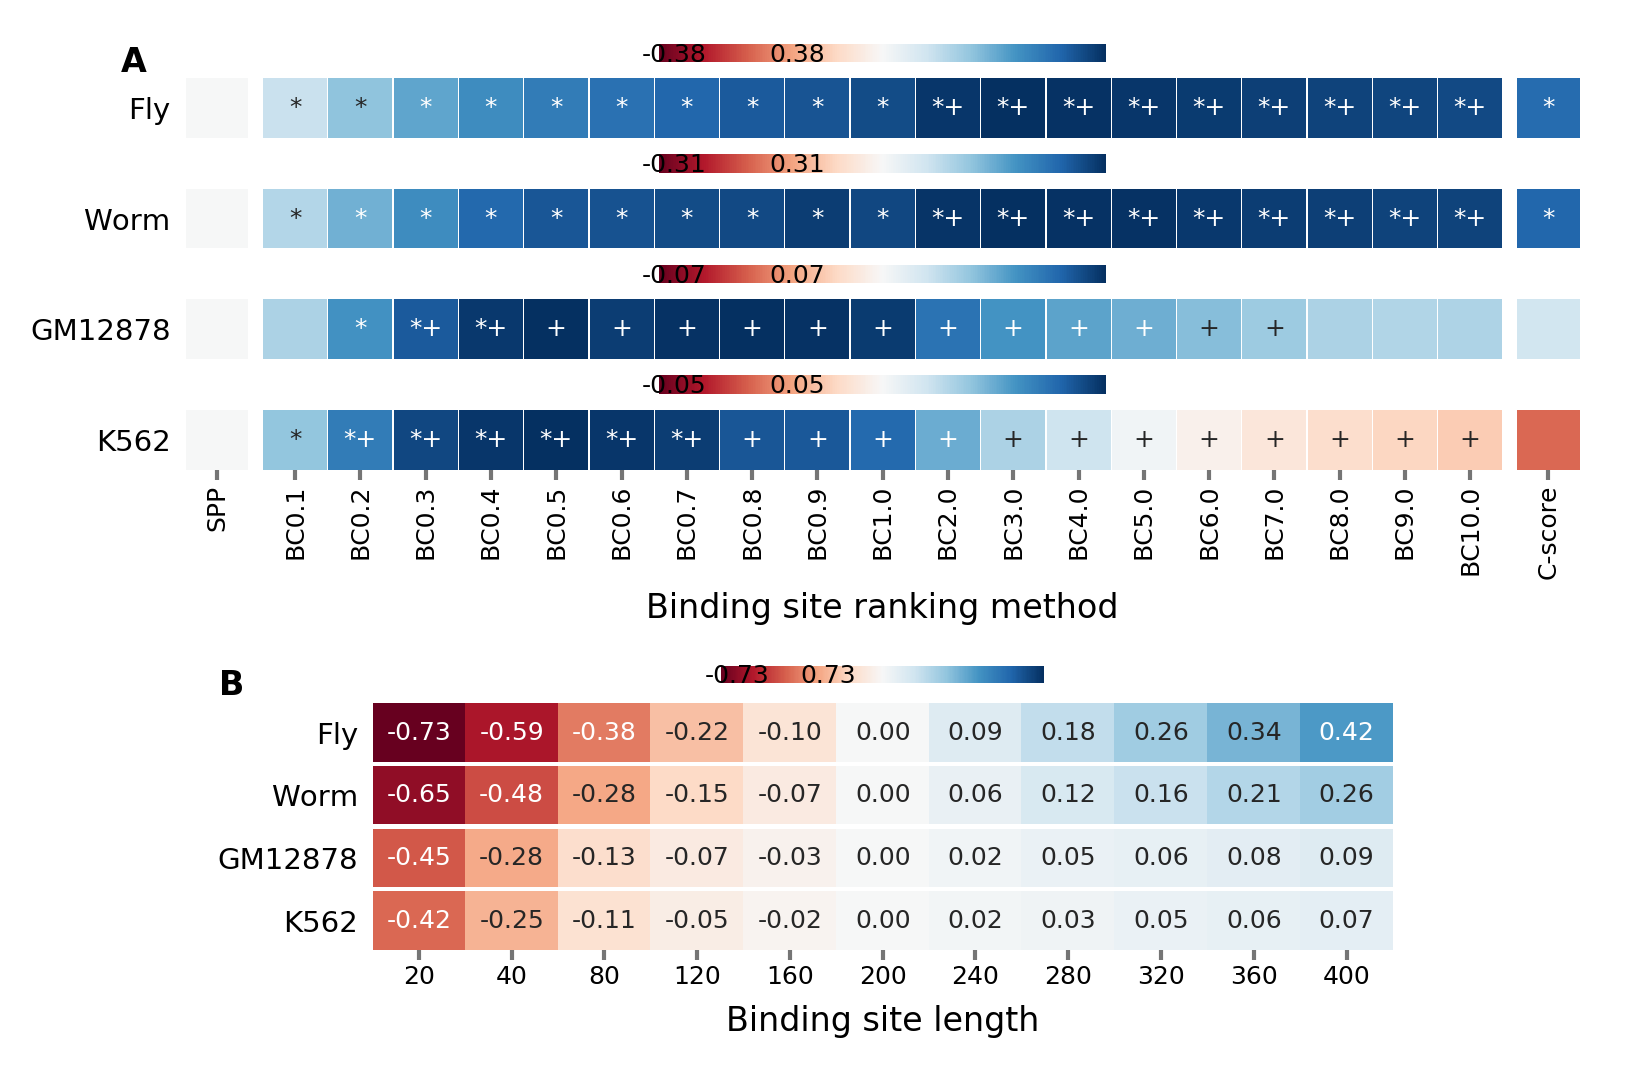

In [8]:
sns.set_context("paper")

fig, axs = plt.subplots(
    nrows=2, ncols=1,
    gridspec_kw={'hspace': 0.55, 'wspace': 0.35, 'height_ratios':[1.5,1]},
    figsize=(6,4), dpi=300)

axs[0].axis('off')
axs[1].axis('off')

################
gs = mpl.gridspec.GridSpecFromSubplotSpec(8, 5, subplot_spec=axs[0], hspace=0.4, wspace=0.05, height_ratios=[0.3,1,0.3,1,0.3,1,0.3,1], width_ratios=[1,6,7,6,1])

##
ax1 = fig.add_subplot(gs[1,0])
ax2 = fig.add_subplot(gs[1,1:4])
ax3 = fig.add_subplot(gs[1,4])
ax_cbar = fig.add_subplot(gs[0,2])

ax1, ax2, ax3 = plt_heatmap_weight(data1, p1, (ax1, ax2, ax3), ax_cbar, "Fly")
ax1.text(-1, 1.1, "A", transform=ax1.transAxes, size=8, weight='bold')


##
ax1 = fig.add_subplot(gs[3,0])
ax2 = fig.add_subplot(gs[3,1:4])
ax3 = fig.add_subplot(gs[3,4])
ax_cbar = fig.add_subplot(gs[2,2])

ax1, ax2, ax3 = plt_heatmap_weight(data2, p2, (ax1, ax2, ax3), ax_cbar, "Worm")

##
ax1 = fig.add_subplot(gs[5,0])
ax2 = fig.add_subplot(gs[5,1:4])
ax3 = fig.add_subplot(gs[5,4])
ax_cbar = fig.add_subplot(gs[4,2])

ax1, ax2, ax3 = plt_heatmap_weight(data3, p3, (ax1, ax2, ax3), ax_cbar, "GM12878")

##
ax1 = fig.add_subplot(gs[7,0])
ax2 = fig.add_subplot(gs[7,1:4])
ax3 = fig.add_subplot(gs[7,4])
ax_cbar = fig.add_subplot(gs[6,2])

ax1, ax2, ax3 = plt_heatmap_weight(data4, p4, (ax1, ax2, ax3), ax_cbar, "K562")

# X labels
ax1.get_xaxis().set_ticklabels(["SPP"],
                               fontsize=6, rotation=90)
ax1.get_xaxis().set_tick_params(size=2.5, pad=1, color="#757575")
ax2.get_xaxis().set_ticklabels(["BC0.1", "BC0.2", "BC0.3", "BC0.4", "BC0.5", "BC0.6", "BC0.7", "BC0.8", "BC0.9", "BC1.0", "BC2.0", "BC3.0", "BC4.0", "BC5.0", "BC6.0", "BC7.0", "BC8.0", "BC9.0", "BC10.0"],
                               fontsize=6, rotation=90)
ax2.get_xaxis().set_tick_params(size=2.5, pad=1, color="#757575")
ax3.get_xaxis().set_ticklabels(["C-score"],
                               fontsize=6, rotation=90)
ax3.get_xaxis().set_tick_params(size=2.5, pad=1, color="#757575")
ax2.set_xlabel("Binding site ranking method", fontsize=8)

################
gs = mpl.gridspec.GridSpecFromSubplotSpec(nrows=6, ncols=5, subplot_spec=axs[1], wspace=0.1, hspace=0.1, width_ratios=[0.5,1,1,1,0.5], height_ratios=[0.3, 0.2, 1, 1, 1, 1])

ax_cbar = fig.add_subplot(gs[0, 2])

vmax = max([datalen1.abs().max().values[0], datalen2.abs().max().values[0], datalen3.abs().max().values[0], datalen4.abs().max().values[0]])

#
ax = fig.add_subplot(gs[2, 1:4])
plt_heatmap_length(ax, datalen1.transpose(), "Fly")
ax.text(-0.15, 1.15, "B", transform=ax.transAxes, size=8, weight='bold')

#
ax = fig.add_subplot(gs[3, 1:4])
plt_heatmap_length(ax, datalen2.transpose(), "Worm")

#
ax = fig.add_subplot(gs[4, 1:4])
plt_heatmap_length(ax, datalen3.transpose(), "GM12878")

#
ax = fig.add_subplot(gs[5, 1:4])
ax = sns.heatmap(datalen4.transpose(),
                 ax=ax,
                 vmax=vmax,
                 vmin=-vmax,
                 center=0,
                 cmap=cmap,
                 cbar_ax=ax_cbar,
                 cbar_kws={"orientation":"horizontal"},
                 annot=datalen4.transpose(),
                 annot_kws={"fontsize":6},
                 fmt=".2f")
ax.yaxis.set_ticklabels(["K562"], fontsize=7, rotation=0)
ax.yaxis.set_tick_params(size=0)

ax.xaxis.set_ticklabels([20,40,80,120,160,200,240,280,320,360,400], rotation=0, fontsize=6)
ax.xaxis.set_tick_params(size=2.5, color="#757575", pad=1)
ax.set_xlabel("Binding site length", fontsize=8)

ax_cbar.xaxis.set_ticklabels([])
ax_cbar.xaxis.set_tick_params(size=0)
ax_cbar.annotate("%.2f" % (-vmax), xy=(-17,0.4), fontsize=6, xycoords="axes pixels")
ax_cbar.annotate("%.2f" % (vmax), xy=(79,0.4), fontsize=6, xycoords="axes pixels")


# plt.show()
plt.savefig("./fig3.pdf", dpi="figure", bbox_inches="tight")